In [1]:
import sys
from IPython.display import display, Javascript

def restart_kernel():
    """Restart the Jupyter Notebook kernel to reflect changes in modules and packages."""
    display(Javascript("Jupyter.notebook.kernel.restart()"))
    print("Kernel is restarting...")

restart_kernel()

import numpy as np
import torch
import tensorly as tl
from tensorly.decomposition import parafac
import sparse
import pickle
import os
import numpy.random as rn
import scipy.stats as st
from tensorly.cp_tensor import CPTensor

from bptf import BPTF as BPTF
import bptf

<IPython.core.display.Javascript object>

Kernel is restarting...


# Helper functions

In [2]:
def generate(shp=(30, 30, 20, 10), K=5, alpha=0.1, beta=0.1):
    """Generate a count tensor from the BPTF model.

    PARAMS:
    shp -- (tuple) shape of the generated count tensor
    K -- (int) number of latent components
    alpha -- (float) shape parameter of gamma prior over factors
    beta -- (float) rate parameter of gamma prior over factors

    RETURNS:
    Mu -- (np.ndarray) true Poisson rates
    Y -- (np.ndarray) generated count tensor
    """
    Theta_DK_M = [rn.gamma(alpha, 1./beta, size=(D, K)) for D in shp]
    Mu = tl.cp_to_tensor(CPTensor((None, Theta_DK_M)))
    assert Mu.shape == shp
    Y = rn.poisson(Mu)
    return Mu, Y

def compare_support(X, Y, thr=0.05):
    """
    Compare the binary ‘non-zero’ supports of two fitted tensors.
    Parameters
    ----------
    X, Y : torch.Tensor  (same shape)
        Reconstructions you want to compare.
    thr : float
        Entries ≤ thr are treated as structural zeros.
    Returns
    -------
    dict with TP, FP, FN counts + agreement metrics.
    """
    Sx = X > thr                       # support of your fit
    Sy = Y > thr                       # support of Aaron’s fit

    tp = (Sx &  Sy).sum().item()       # both predict non-zero
    fp = (Sx & ~Sy).sum().item()       # you only
    fn = (~Sx & Sy).sum().item()       # Aaron only
    union = (Sx | Sy).sum().item()

    precision = tp / (tp + fp) if tp + fp else 1.0
    recall    = tp / (tp + fn) if tp + fn else 1.0
    f1        = 2*precision*recall / (precision + recall) if precision+recall else 0.0
    jaccard   = tp / union if union else 1.0

    return dict(tp=tp, fp=fp, fn=fn,
                precision=precision, recall=recall,
                f1=f1, jaccard=jaccard)

# Generate data

In [3]:
use_existing_data = True

rn.seed(0)

if use_existing_data:
    assert os.path.exists('sptensor.pkl'), 'No such file.'
    with open('sptensor.pkl', 'rb') as f:
        data = pickle.load(f)
    data = data[:, :, :, :12, :]
    data = sparse.COO(data)
    print(f'Percentage of cells that are non-zero: {data.data.shape[0] / np.prod(np.array(list(data.shape))) * 100: .3}%')
else:
    data = generate(shp=(200, 200, 20, 12, 3), K=10)[1]
    data = sparse.COO(data)

Percentage of cells that are non-zero:  0.713%


# Fit with BPTF

In [4]:
n_components = 50
max_iter = 500
device = 'cuda'
tol = 1e-6

mask = np.zeros(data.shape)
# april of GDELT is set to missing
mask[:, :, :, 3, 1] = 1

# diagonals are set to missing
mask[np.eye(mask.shape[0]).astype(bool)] = 1
mask = sparse.COO(mask.astype(np.int64))

# BPTF_model_withmask = BPTF(data_shape=data.shape, n_components=n_components)
# BPTF_model_withmask.fit(data, mask = mask, max_iter = max_iter, verbose=False, missing_val=1, tol=tol)

BPTF_model_nomask = BPTF(data_shape=data.shape, n_components=n_components)
BPTF_model_nomask.fit(data, mask = None, max_iter = max_iter, verbose=False, missing_val=1, tol=tol)

  0%|          | 0/500 [00:00<?, ?it/s]

Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 0]  min uttkrp_DK = 1.730e+05
[mode 0]  min new rate = 1.730e+05   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 1]  min uttkrp_DK = 3.886e+02
[mode 1]  min new rate = 3.887e+02   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 2]  min uttkrp_DK = 4.234e+03
[mode 2]  min new rate = 4.234e+03   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 3]  min uttkrp_DK = 5.421e+03
[mode 3]  min new rate = 5.421e+03   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


...

Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 2]  min uttkrp_DK = 2.026e+03
[mode 2]  min new rate = 2.027e+03   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 3]  min uttkrp_DK = 3.313e+03
[mode 3]  min new rate = 3.314e+03   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


Are the shape parameters positive? True
Are the rate parameters positive? True
Are the shape parameters finite? True
Are the rate parameters finite? True
[mode 4]  min uttkrp_DK = 1.305e+04
[mode 4]  min new rate = 1.305e+04   negatives = 0
Is G_DK_M finite before updating? True
Are there NaNs in G_DK_M after updating cache? False
Is G_DK_M finite after updating? True


 35%|███▌      | 175/500 [07:55<14:42,  2.72s/it]

BPTF(data_shape=(280, 280, 20, 12, 3), n_components=50)

# Fit with own BPTF_torch

In [5]:
from own_implementation import BPTF as BPTF_torch

  0%|          | 0/500 [00:00<?, ?it/s]

ELBO =  8416888.026, change =  1.0, time taken =  0.265, mem alloc =  0.913GB:   0%|          | 0/500 [00:00<?, ?it/s]

ELBO =  8416888.026, change =  1.0, time taken =  0.265, mem alloc =  0.913GB:   0%|          | 1/500 [00:00<02:13,  3.74it/s]

ELBO =  8705681.585, change =  0.0343, time taken =  0.263, mem alloc =  0.913GB:   0%|          | 1/500 [00:00<02:13,  3.74it/s]

ELBO =  8705681.585, change =  0.0343, time taken =  0.263, mem alloc =  0.913GB:   0%|          | 2/500 [00:00<02:12,  3.76it/s]

...

ELBO =  19236711.639, change =  1.05e-06, time taken =  0.263, mem alloc =  0.913GB:  34%|███▍      | 169/500 [00:45<01:27,  3.76it/s]

ELBO =  19236711.639, change =  1.05e-06, time taken =  0.263, mem alloc =  0.913GB:  34%|███▍      | 170/500 [00:45<01:27,  3.77it/s]

ELBO =  19236730.704, change =  9.91e-07, time taken =  0.263, mem alloc =  0.913GB:  34%|███▍      | 170/500 [00:45<01:27,  3.77it/s]

Change is small enough, early break:  34%|███▍      | 170/500 [00:45<01:27,  3.77it/s]                                                

Change is small enough, early break:  34%|███▍      | 170/500 [00:45<01:28,  3.74it/s]

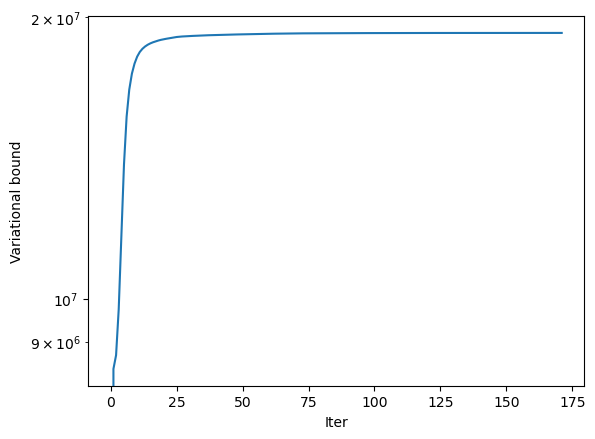

BPTF(alpha=tensor([0.1000], device='cuda:0'),
     data_shape=torch.Size([280, 280, 20, 12, 3]), device='cuda',
     n_components=50)

In [6]:
mask = (1 - mask.todense()).astype(np.int64)
mask = torch.tensor(mask, dtype=torch.float64, device=device)

data = torch.tensor(data.todense(), dtype = torch.float64, device=device)
BPTF_model_torch_nomask = BPTF_torch(data_shape=data.shape, n_components=n_components, device=device)
BPTF_model_torch_nomask.fit(data, mask = None, max_iter = max_iter, verbose=True, tol=tol)

# BPTF_model_torch_withmask = BPTF_torch(data_shape=data.shape, n_components=n_components, device=device)
# BPTF_model_torch_withmask.fit(data, mask = mask, max_iter = max_iter, verbose=True, tol=tol)

# Check similarity

## No mask

Frobenius norm relative difference: 0.37330447328443944
Proportion of elements with difference greater than 0.05 = 0.04294967049319728
tensor(1.1228, device='cuda:0') tensor(0.1699, device='cuda:0') tensor(5432.5625, device='cuda:0')


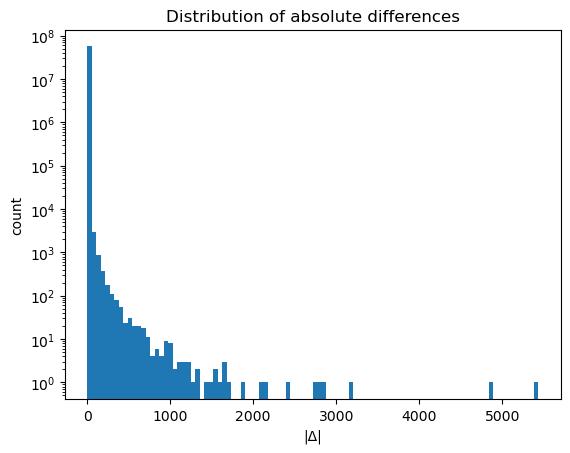

tensor([199542, 192077, 199386, 211076, 222157, 227350, 195556, 199456, 196189,
        201933, 200441, 179260], device='cuda:0')
{'tp': 2964505, 'fp': 510164, 'fn': 541322, 'precision': 0.8531762305992312, 'recall': 0.845593635966635, 'f1': 0.8493680105253265, 'jaccard': 0.7381752100540065}
(array([121, 203, 121, 203, 121, 121, 121, 126, 203, 121, 121, 203, 121,
       121, 203,  47, 121, 121, 121, 121]), array([121, 203, 121, 203, 203, 203, 138, 126, 121, 121, 203, 203, 203,
       203, 121,  47, 138, 203, 138, 203]), array([18, 18, 18, 18, 18,  7, 18,  3,  3, 18, 18, 18, 18,  7, 10,  3,  7,
       18, 18,  7]), array([ 9,  9, 10, 10,  4,  9,  9,  6,  9, 11,  2, 11,  1, 10,  9,  5,  4,
        3, 10,  4]), array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]))


/tmp/ipykernel_1656593/610081698.py:31: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  print(np.unravel_index(idx.cpu(), diff.shape))


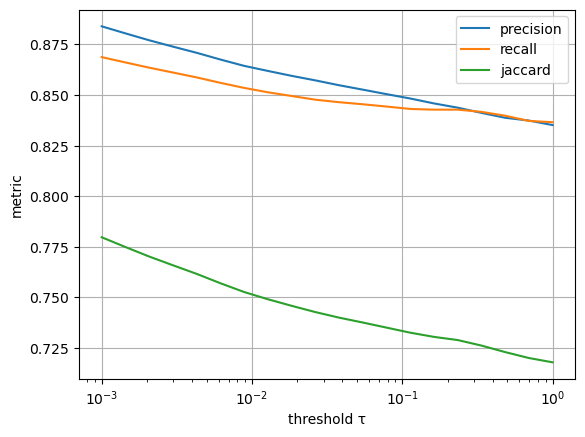

In [7]:
BPTF_G_DK_M = [torch.tensor(factor_matrix, dtype=torch.float64, device=device) for factor_matrix in BPTF_model_nomask.G_DK_M]
fro_norm_rel_diff = torch.norm(BPTF_model_torch_nomask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro') / torch.norm(tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro')
print(f'Frobenius norm relative difference: {fro_norm_rel_diff}')

threshold = 0.05
diff = torch.abs(BPTF_model_torch_nomask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)))
prop_exceed = (diff > threshold).sum().item() / diff.numel()
print(f'Proportion of elements with difference greater than {threshold} = {prop_exceed}')

# 1) How big are the large errors?
big = diff[diff > 0.05]
print(big.mean(), big.median(), big.max())

# 2) Histogram of the absolute differences
import matplotlib.pyplot as plt
plt.hist(diff.flatten().cpu().numpy(), bins=100, log=True)
plt.xlabel('|Δ|'); plt.ylabel('count'); plt.title('Distribution of absolute differences')
plt.show()

# 3) Where do they occur?  Example for mode-4 time slices
exceed_mask = (diff > 0.05)
time_exceed = exceed_mask.view(data.shape).sum(dim=(0,1,2,4))
print(time_exceed)  # counts per month

# Check whether the predictions for nnz locations are the same
nnz_prediction_stats = compare_support(BPTF_model_torch_nomask.reconstruct(style='geometric'), tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), thr=0.05)
print(nnz_prediction_stats)

diff = (BPTF_model_torch_nomask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M))).abs()
idx   = diff.flatten().topk(20).indices
print(np.unravel_index(idx.cpu(), diff.shape))

thrs = np.logspace(-3, 0, 20)          # 0.001 … 1
stats = [compare_support(BPTF_model_torch_nomask.reconstruct(style='geometric'), tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), thr=t) for t in thrs]

prec = [s['precision'] for s in stats]
rec  = [s['recall']    for s in stats]
jacc = [s['jaccard']   for s in stats]

plt.semilogx(thrs, prec, label='precision')
plt.semilogx(thrs, rec,  label='recall')
plt.semilogx(thrs, jacc, label='jaccard')
plt.xlabel('threshold τ'); plt.ylabel('metric'); plt.legend(); plt.grid(True)
plt.show()

## With mask

In [8]:
# BPTF_G_DK_M = [torch.tensor(factor_matrix, dtype=torch.float64, device=device) for factor_matrix in BPTF_model_withmask.G_DK_M]
# fro_norm_rel_diff = torch.norm(BPTF_model_torch_withmask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro') / torch.norm(tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)), 'fro')
# print(f'Frobenius norm relative difference: {fro_norm_rel_diff}')

# threshold = 0.05
# diff = torch.abs(BPTF_model_torch_withmask.reconstruct(style='geometric') - tl.cp_tensor.cp_to_tensor((None, BPTF_G_DK_M)))
# prop_exceed = (diff > threshold).sum().item() / diff.numel()
# print(f'Proportion of elements with difference greater than {threshold} = {prop_exceed}')

# # 1) How big are the large errors?
# big = diff[diff > 0.05]
# print(big.mean(), big.median(), big.max())

# # 2) Histogram of the absolute differences
# import matplotlib.pyplot as plt
# plt.hist(diff.flatten().cpu().numpy(), bins=100, log=True)
# plt.xlabel('|Δ|'); plt.ylabel('count'); plt.title('Distribution of absolute differences')

# # 3) Where do they occur?  Example for mode-4 time slices
# exceed_mask = (diff > 0.05)
# time_exceed = exceed_mask.view(data.shape).sum(dim=(0,1,2,4))
# print(time_exceed)  # counts per month